# 01 — Acoustic cavity modes: CHEXA8 against the closed form

**A rigid-walled air cavity, loaded from whatever file you pick, meshed with
`CHEXA8` acoustic elements: the first twelve modes compared with the
analytical ones, one by one.**

The cavity must be a **rectangular box**, because the box is the case whose
modes are known exactly:

$$ p_{lmn} = \cos\frac{l\pi x}{L_x}\cos\frac{m\pi y}{L_y}\cos\frac{n\pi z}{L_z},
   \qquad
   f_{lmn} = \frac{c_0}{2}\sqrt{\Bigl(\frac{l}{L_x}\Bigr)^{2}
   + \Bigl(\frac{m}{L_y}\Bigr)^{2} + \Bigl(\frac{n}{L_z}\Bigr)^{2}} $$

so every computed frequency has something to be checked against. The
dimensions and the element counts are **not written here**: they are read off
the mesh that arrives. Any geometry that is not such a box — a duct meshed in
tetrahedra, a cavity with a flexible wall, a mesh too coarse for the twelfth
mode — is **refused** in section 2 instead of being compared with a formula
that does not describe it.

---
## 1 — Which run, and what it is made of

The same opening as every other example: state the run and the materials
first, then ask where the geometry is.

Here the run is `"acoustic"` — the fluid alone, rigid walls, no structure.
Rigid walls need no boundary condition: $\partial p/\partial n = 0$ is the
natural one, so nothing is constrained and nothing has to be said about the
six faces.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))          # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import pycafe
from pycafe.core.model_spec import (
    AIR, ModelSpec, build_mesh, build_model, describe_domains,
)
from pycafe.create_geom import ask_for_geometry
from pycafe.create_geom.visualize_mesh import load_mesh_with_groups
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# what kind of run: the fluid alone
ANALYSIS = "acoustic"

# one material per domain of that run - here there is only the one
FLUID = AIR
STRUCTURE = None

F_MAX = 1000.0        # highest frequency the mesh has to resolve [Hz]
N_MODES = 12          # modes compared with the closed form
MAX_NODES = 40_000    # this notebook solves the full K, M in memory

C0 = FLUID.c0
print(f"{ANALYSIS} run up to {F_MAX:.0f} Hz, c0 = {C0:.0f} m/s")

acoustic run up to 1000 Hz, c0 = 343 m/s


---
## 2 — Where the geometry comes from

`ask_for_geometry()` opens one dialog on `../Library/` and reads whatever is
picked: a `.msh` as it stands, a `.step` meshed here at the size `F_MAX` asks
for, a `.bdf` read from its property cards. `Library/box_cavity.msh` is the
one this notebook was written around — a 0.40 × 0.30 × 0.50 m air box, built
for 1000 Hz.

**There is no fallback file.** A cancelled dialog raises, and so does a file
that is not a rigid rectangular cavity: an example that quietly went on with
some other geometry would still print a perfectly reasonable-looking table of
errors against the wrong analytical modes.

In [2]:
geometry = ask_for_geometry()      # a dialog; no answer, no geometry
print()
print(type(geometry).__name__, "->", geometry)

spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,             # what to look for, and what to assemble
    fluid=FLUID,
    f_max=F_MAX,
    work_dir=".",
)
print()
print(spec.describe())

mesh_path, report = build_mesh(spec)    # mesh it, or just check it, then validate
print()
print(report)
print(describe_domains(report, FLUID, STRUCTURE))

using /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh
box_cavity.msh: a mesh, used as it is (its physical groups already carry the roles).

MeshFile -> MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh'), rename={}, drop=())

ModelSpec
  geometry     MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh'), rename={}, drop=())
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  f_max        1000.0 Hz (lambda = 343 mm)
  mesh size    34.3 mm (10 elements per wavelength)
  mesh file    /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh

/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh  (acoustic analysis)
-----------------------------------------------------------------------------------
  2080 nodes, 846 x Quadrilateral 4, 1620 x Hexahedron 8
  roles: fluid = 'fluid'
  · fluid element size: 33.3 / 33.3 / 33.3 mm (min / mean / max)
  · good to ~1% up to 792 Hz (13 elements

### What this notebook refuses

`build_mesh` has already checked the mesh against the pyCAFE contract: a
fluid group exists, and it resolves `F_MAX`. That is not enough here. This
notebook compares against a closed form, so it needs four more things, and
each of them is a reason to stop rather than to warn:

| refused | why |
|---|---|
| a structural group | this is the *rigid* cavity; a flexible wall is notebook 02 |
| tetrahedra, prisms | the mode shapes are read off a structured grid of `CHEXA8` |
| nodes that do not fill a grid | then the cavity is not a rectangular box, and $f_{lmn}$ describes nothing |
| a mesh too coarse for mode 12 | below 10 elements per wavelength the error reported would be the dispersion of the mesh, not a validation |

What comes back is the only thing the rest of the notebook needs: the three
sides of the box and the three element counts, **measured on the mesh**.

In [3]:
def read_rectangular_cavity(mesh_path, report):
    """Sides and element counts of the box, or a refusal naming what is wrong.

    Returns ``(axes, L, n_elements)``: the distinct nodal coordinates along
    x, y and z, the three sides in metres, and the elements per direction.
    """
    nodes, elements, _boundaries, _groups = load_mesh_with_groups(
        str(mesh_path), verbose=False
    )
    problems = []

    if "structure" in report.roles:
        problems.append(
            f"it carries a structural group ('{report.roles['structure']}'), so "
            "its walls are not rigid - that case is notebook 02"
        )

    hexes = elements.get("Hexahedron 8")
    unstructured = [name for name in elements
                    if name.startswith(("Tetrahedron", "Prism", "Pyramid"))]
    if hexes is None:
        problems.append("it holds no CHEXA8: a box is meshed in hexahedra")
    if unstructured:
        problems.append(
            f"it holds {', '.join(unstructured)}, which form no structured grid"
        )

    axes = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
    counts = np.array([a.size for a in axes])
    if counts.min() < 2:
        problems.append(
            f"it is not three-dimensional: {' x '.join(map(str, counts))} "
            "distinct nodal coordinates"
        )
    elif counts.prod() != nodes.shape[0]:
        problems.append(
            f"its {nodes.shape[0]} nodes do not fill the "
            f"{' x '.join(map(str, counts))} grid its coordinates span, so the "
            "fluid is not a rectangular box meshed structurally"
        )
    elif hexes is not None and len(hexes) != (counts - 1).prod():
        problems.append(
            f"{len(hexes)} hexahedra where a full "
            f"{' x '.join(map(str, counts - 1))} box has "
            f"{(counts - 1).prod()}: the grid has holes"
        )

    if report.n_nodes > MAX_NODES:
        problems.append(
            f"{report.n_nodes} nodes, above the {MAX_NODES} this example solves "
            "in memory: pick a smaller cavity, or lower F_MAX"
        )

    L = np.array([a[-1] - a[0] for a in axes])
    if not problems:
        h = max(np.diff(a).max() for a in axes)
        f_last = np.sort([C0 / 2 * np.sqrt(((np.array(idx) / L) ** 2).sum())
                          for idx in np.ndindex(6, 6, 6) if any(idx)])[N_MODES - 1]
        per_wavelength = C0 / (f_last * h)
        if per_wavelength < 10.0:
            problems.append(
                f"mode {N_MODES} of this cavity is at {f_last:.0f} Hz and the mesh "
                f"gives {per_wavelength:.1f} elements per wavelength there, below "
                "the 10 this comparison needs: pick a finer mesh"
            )

    if problems:
        raise RuntimeError(
            f"{os.path.basename(str(mesh_path))} is not the geometry this "
            "notebook validates:\n  - " + "\n  - ".join(problems)
            + "\n\nRun it again on a rigid rectangular cavity "
              "(../Library/box_cavity.msh is one)."
        )
    return axes, L, counts - 1


AXES, (LX, LY, LZ), (NX, NY, NZ) = read_rectangular_cavity(mesh_path, report)

print(f"rigid box {LX:.3f} x {LY:.3f} x {LZ:.3f} m")
print(f"meshed {NX} x {NY} x {NZ} = {NX * NY * NZ} CHEXA8, "
      f"{(NX + 1) * (NY + 1) * (NZ + 1)} pressure DOFs")

rigid box 0.400 x 0.300 x 0.500 m
meshed 12 x 9 x 15 = 1620 CHEXA8, 2080 pressure DOFs


---
## 3 — Picture first, then the matrices

`build_model` does the whole front end in one call: mesh, validate, **draw the
geometry coloured by role**, assemble. The picture comes before the numbers on
purpose — a cavity read in the wrong unit, or a mesh that is not the one meant,
shows up there and in none of the frequencies.

The element size was never typed: for a geometry meshed here it follows from
`F_MAX` and the ten-elements-per-wavelength rule, $h = c_0/(f_{max} n_\lambda)$;
for a mesh loaded as it stands, `F_MAX` only says what it is checked against.

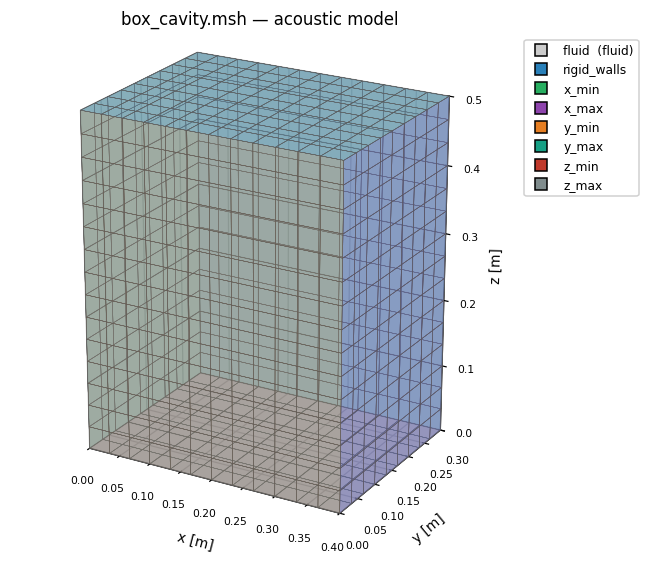

Acoustic domain from physical group 'fluid': CHEXA8


walls  : rigid (dp/dn = 0 is the natural BC - no DOF is constrained)
assembled: acoustic -> ['C', 'C_op', 'C_red', 'C_red_op', 'K', 'K_red', 'M', 'M_red', 'bc', 'bc_velocity', 'boundary_dim', 'debug', 'elem_type', 'idx_free', 'p0_nodes', 'pml_op', 'pml_red_op', 'pressure_nodes_red', 'pressure_values', 'radiation_op', 'radiation_red_op', 'source_op', 'source_red_op', 'value_velocity_normal', 'velocity_op', 'velocity_red_op']


In [4]:
model = build_model(spec)               # mesh -> validate -> draw -> assemble

nodes = model["nodes"]
system = model["system"]

print("walls  : rigid (dp/dn = 0 is the natural BC - no DOF is constrained)")
print("assembled:", model["analysis"], "->", sorted(system))

---
## 4 — Modal analysis

The uniform-pressure mode $(0,0,0)$ at $f = 0$ is a genuine solution of the
rigid cavity and is discarded by the solver. Each computed mode is labelled by
correlating it with the analytical shapes, so the pairing is safe even when two
frequencies are close.

The analytical shapes are written about the corner of the box, so the nodal
coordinates are measured from it — a cavity drawn anywhere else in space is
compared just as well.

In [5]:
K, M = system["K"], system["M"]
freqs, modes = solve_modal_acoustic_reduced(K, M, num_modes=N_MODES)

L = np.array([LX, LY, LZ])
ORIGIN = np.array([a[0] for a in AXES])          # the corner of the box
XYZ = nodes - ORIGIN

CANDIDATES = [(l, m, n) for l in range(5) for m in range(5) for n in range(5)
              if (l, m, n) != (0, 0, 0)]
SHAPES = np.array([np.cos(l * np.pi * XYZ[:, 0] / LX)
                   * np.cos(m * np.pi * XYZ[:, 1] / LY)
                   * np.cos(n * np.pi * XYZ[:, 2] / LZ)
                   for l, m, n in CANDIDATES])


def identify(v):
    '''(l,m,n) of the analytical mode best correlated with the FE mode.'''
    mac = (SHAPES @ v) ** 2 / ((SHAPES * SHAPES).sum(axis=1) * (v @ v))
    return CANDIDATES[int(mac.argmax())]


def exact_frequency(idx):
    return C0 / 2 * np.sqrt(sum((idx[i] / L[i]) ** 2 for i in range(3)))


labels = [identify(modes[:, i]) for i in range(N_MODES)]
exact = np.array([exact_frequency(idx) for idx in labels])
error = (freqs - exact) / exact * 100

print(f"{'mode':>5s} {'(l,m,n)':>10s} {'analytical [Hz]':>17s}"
      f" {'pyCAFE [Hz]':>13s} {'error [%]':>11s}")
for i in range(N_MODES):
    print(f"{i+1:5d} {str(labels[i]):>10s} {exact[i]:17.2f}"
          f" {freqs[i]:13.2f} {error[i]:11.3f}")
print(f"\nmean error {np.abs(error).mean():.3f} % - "
      f"max error {np.abs(error).max():.3f} %")

 mode    (l,m,n)   analytical [Hz]   pyCAFE [Hz]   error [%]
    1  (0, 0, 1)            343.00        343.63       0.183
    2  (1, 0, 0)            428.75        429.98       0.286
    3  (1, 0, 1)            549.07        550.42       0.246
    4  (0, 1, 0)            571.67        574.57       0.508
    5  (0, 1, 1)            666.67        669.49       0.422
    6  (0, 0, 2)            686.00        691.03       0.733
    7  (1, 1, 0)            714.58        717.64       0.428
    8  (1, 1, 1)            792.64        795.67       0.382
    9  (1, 0, 2)            808.96        813.88       0.607
   10  (2, 0, 0)            857.50        867.33       1.146
   11  (0, 1, 2)            892.97        898.69       0.641
   12  (2, 0, 1)            923.56        932.92       1.014

mean error 0.550 % - max error 1.146 %


---
## 5 — Mode shapes

Acoustic pressure on the cavity walls. Rigid walls force a pressure antinode on
every boundary, so the field on the six faces shows the complete mode pattern:
one nodal plane (white) per unit of the corresponding index.

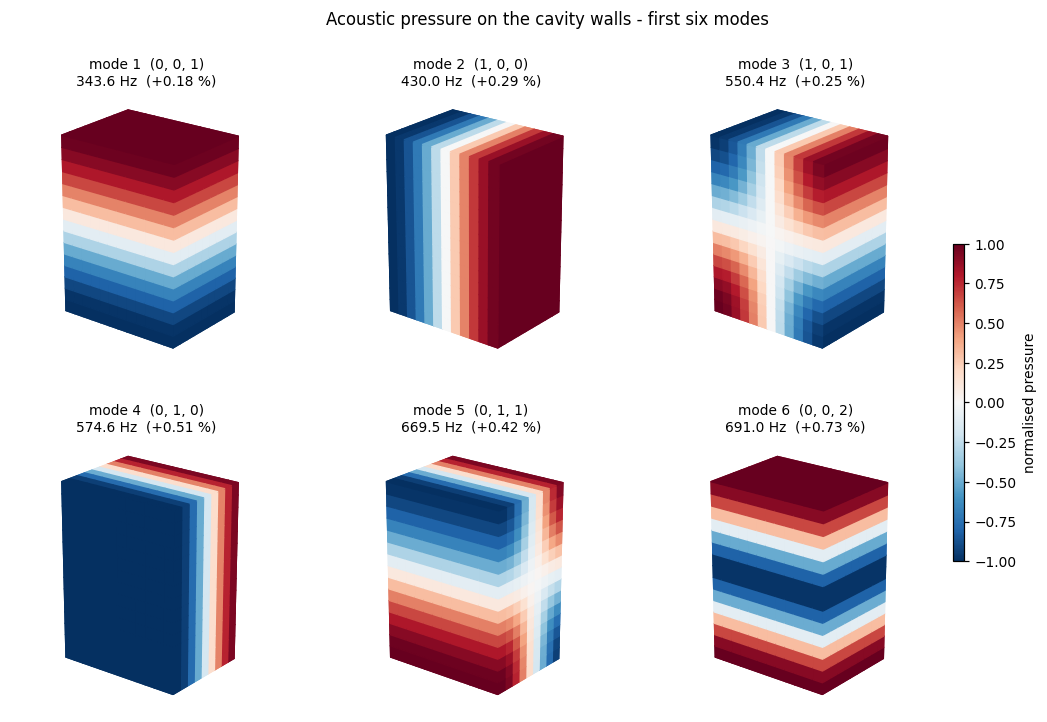

In [6]:
# Gmsh numbers the nodes its own way, so the structured grid is recovered
# from the coordinates: GRID[i, j, k] is the node at (x_i, y_j, z_k).
xs, ys, zs = AXES
ix = np.searchsorted(xs, np.round(nodes[:, 0], 9))
iy = np.searchsorted(ys, np.round(nodes[:, 1], 9))
iz = np.searchsorted(zs, np.round(nodes[:, 2], 9))
GRID = np.empty((xs.size, ys.size, zs.size), dtype=int)
GRID[ix, iy, iz] = np.arange(nodes.shape[0])


def plot_cavity_mode(ax, p, title, cmap="RdBu_r"):
    '''Cavity walls coloured by the nodal pressure field.'''
    P = p[GRID]
    P = P / np.abs(P).max()
    if P.ravel()[np.abs(P).argmax()] < 0:
        P = -P
    x, y, z = xs, ys, zs
    norm = plt.Normalize(-1, 1)
    colors = plt.get_cmap(cmap)

    Y, Z = np.meshgrid(y, z, indexing="ij")
    for i, xv in ((0, x[0]), (-1, x[-1])):
        ax.plot_surface(np.full_like(Y, xv), Y, Z, rstride=1, cstride=1,
                        facecolors=colors(norm(P[i])), shade=False)
    X, Z = np.meshgrid(x, z, indexing="ij")
    for j, yv in ((0, y[0]), (-1, y[-1])):
        ax.plot_surface(X, np.full_like(X, yv), Z, rstride=1, cstride=1,
                        facecolors=colors(norm(P[:, j])), shade=False)
    X, Y = np.meshgrid(x, y, indexing="ij")
    for k, zv in ((0, z[0]), (-1, z[-1])):
        ax.plot_surface(X, Y, np.full_like(X, zv), rstride=1, cstride=1,
                        facecolors=colors(norm(P[:, :, k])), shade=False)

    ax.set_box_aspect((LX, LY, LZ))
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()
    ax.view_init(elev=22, azim=-52)


fig = plt.figure(figsize=(13, 7.5))
for i in range(6):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    plot_cavity_mode(ax, modes[:, i],
                     f"mode {i+1}  {labels[i]}\n{freqs[i]:.1f} Hz  "
                     f"({error[i]:+.2f} %)")
fig.suptitle("Acoustic pressure on the cavity walls - first six modes", y=0.97)
fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"),
             ax=fig.axes, shrink=0.5, aspect=30, pad=0.02,
             label="normalised pressure")
plt.show()

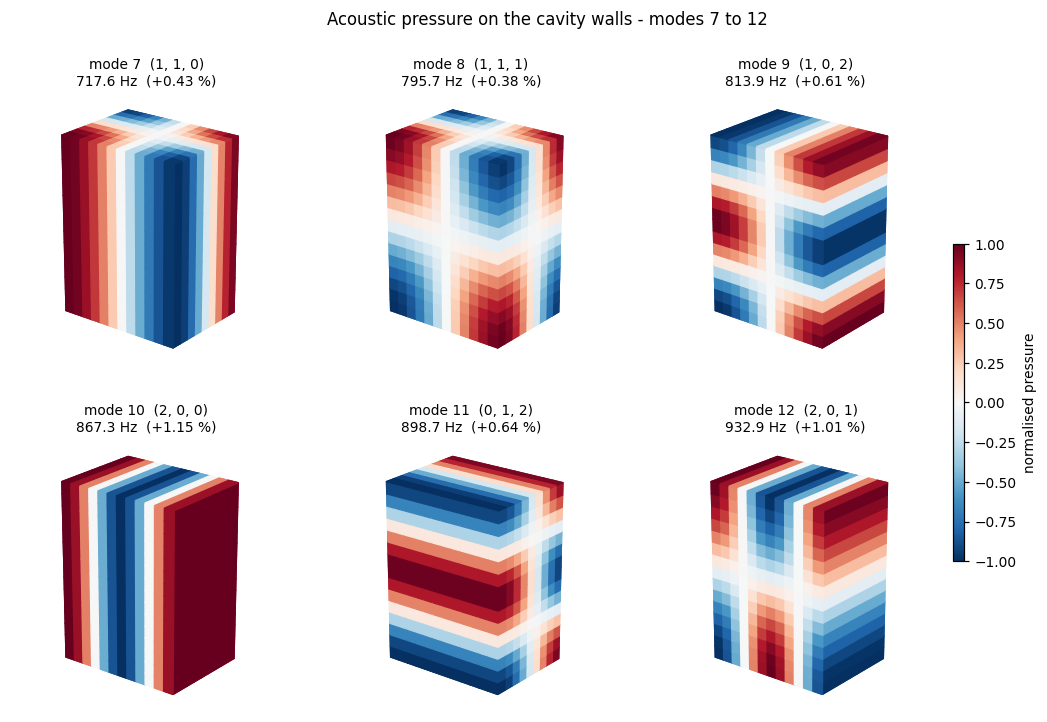

In [7]:
fig = plt.figure(figsize=(13, 7.5))
for i in range(6, N_MODES):
    ax = fig.add_subplot(2, 3, i - 5, projection="3d")
    plot_cavity_mode(ax, modes[:, i],
                     f"mode {i+1}  {labels[i]}\n{freqs[i]:.1f} Hz  "
                     f"({error[i]:+.2f} %)")
fig.suptitle(f"Acoustic pressure on the cavity walls - modes 7 to {N_MODES}",
             y=0.97)
fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"),
             ax=fig.axes, shrink=0.5, aspect=30, pad=0.02,
             label="normalised pressure")
plt.show()

---
## Summary

Whatever rectangular cavity was picked, the first twelve modes come out with
every shape matching its analytical $(l,m,n)$ pattern and an error of the order
of one per cent — the table above says exactly how much for the mesh that was
loaded. On `Library/box_cavity.msh` (0.40 × 0.30 × 0.50 m, 12 × 9 × 15 `CHEXA8`,
2080 pressure DOFs) it is a **mean of 0.55 %** and a **maximum of 1.1 %**.

The deviation is the numerical dispersion of a trilinear element and it is
always positive — the discretised cavity is slightly stiffer than the
continuum. It scales with the square of the mesh size, so it shrinks by a
factor of four every time the mesh is halved: rebuild the same case at twice
the `f_max` (`Library/make_library.py`) and the errors above divide by four.